# Ensemble com Multi-Crop TTA — DenseNet201 + DenseNet169 + EfficientNetB4

Este notebook testa uma variação do TTA usando **multi-crop/janelamento probabilístico**.

A ideia é diferente do janelamento tradicional que salva várias imagens em pastas. Aqui, a imagem é carregada, recortada pela máscara da lesão, transformada em múltiplas janelas/crops, avaliada pelos modelos e combinada pela média ponderada das probabilidades.

Modelos usados:

- **Modelo A:** DenseNet201 + Crop + SMOTE + 320x320;
- **Modelo B:** DenseNet169 + Crop + SMOTE + 256x256;
- **Modelo C:** EfficientNetB4 + Crop + SMOTE + 380x380.

O notebook não treina novamente. Ele apenas avalia os modelos salvos usando **multi-crop TTA** e ensemble ponderado.

## 1. Imports

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import random
from pathlib import Path
import json
from datetime import datetime

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

## 2. Configurações gerais

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = Path("../data")
IMAGES_DIR = DATA_DIR / "images"
MASKS_DIR = DATA_DIR / "masks"
CSV_PATH = DATA_DIR / "GroundTruth.csv"

TEST_SIZE = 0.20

classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]
class_code = {label: idx for idx, label in enumerate(classes)}
class_name = {idx: label for label, idx in class_code.items()}

print(class_code)

{'MEL': 0, 'NV': 1, 'BCC': 2, 'AKIEC': 3, 'BKL': 4, 'DF': 5, 'VASC': 6}


## 3. Conferir arquivos `.keras` disponíveis

In [3]:
for file in os.listdir():
    if file.endswith(".keras"):
        print(file)

encoder_decoder_segmenter.keras
segmented_densenet169_dull_smote_final.keras
best_densenet169_dull_crop_smote.keras
best_deepskin_densenet169_undersampling.keras
efficientnetb4_crop_380_feature_extractor.keras
best_segmented_densenet169_dull_smote.keras
best_efficientnetb4_crop_smote_380.keras
segmented_densenet169_feature_extractor.keras
deepskin_densenet169_undersampling_final.keras
best_segmented_densenet169_dull_undersampling.keras
densenet169_dull_crop_feature_extractor.keras
efficientnetb3_crop_320_feature_extractor.keras
efficientnetb4_crop_smote_380_final.keras
densenet169_feature_extractor.keras
densenet201_crop_320_feature_extractor.keras
segmented_densenet169_dull_undersampling_final.keras
densenet201_crop_smote_256_final.keras
best_efficientnetb3_crop_smote_320.keras
best_densenet169_undersampling.keras
deepskin_densenet169_smote_final.keras
best_densenet201_crop_smote_320.keras
densenet169_dull_crop_smote_final.keras
efficientnetb3_crop_smote_320_final.keras
best_deepskin_

## 4. Configurações dos modelos

In [4]:
# Modelo A: DenseNet201 + Crop + SMOTE + 320x320
IMG_SIZE_A = (320, 320)
FEATURE_EXTRACTOR_A_PATH = "densenet201_crop_320_feature_extractor.keras"
CLASSIFIER_A_PATH = "best_densenet201_crop_smote_320.keras"

# Modelo B: DenseNet169 + Crop + SMOTE + 256x256
IMG_SIZE_B = (256, 256)
FEATURE_EXTRACTOR_B_PATH = "densenet169_dull_crop_feature_extractor.keras"
CLASSIFIER_B_PATH = "best_densenet169_dull_crop_smote.keras"

# Modelo C: EfficientNetB4 + Crop + SMOTE + 380x380
IMG_SIZE_C = (380, 380)
FEATURE_EXTRACTOR_C_PATH = "efficientnetb4_crop_380_feature_extractor.keras"
CLASSIFIER_C_PATH = "best_efficientnetb4_crop_smote_380.keras"

# Pré-processamento usado nos melhores modelos
USE_DULL_RAZOR = False
USE_MASK_SEGMENTATION = False
USE_MASK_CROP = True
CROP_MARGIN = 20

# Pesos iniciais do melhor ensemble com 3 modelos
WEIGHT_MODEL_A = 0.70
WEIGHT_MODEL_B = 0.20
WEIGHT_MODEL_C = 0.10

print("Modelo A:", IMG_SIZE_A, FEATURE_EXTRACTOR_A_PATH, CLASSIFIER_A_PATH)
print("Modelo B:", IMG_SIZE_B, FEATURE_EXTRACTOR_B_PATH, CLASSIFIER_B_PATH)
print("Modelo C:", IMG_SIZE_C, FEATURE_EXTRACTOR_C_PATH, CLASSIFIER_C_PATH)
print("Pesos:", WEIGHT_MODEL_A, WEIGHT_MODEL_B, WEIGHT_MODEL_C)

assert abs((WEIGHT_MODEL_A + WEIGHT_MODEL_B + WEIGHT_MODEL_C) - 1.0) < 1e-6, "Os pesos devem somar 1."

Modelo A: (320, 320) densenet201_crop_320_feature_extractor.keras best_densenet201_crop_smote_320.keras
Modelo B: (256, 256) densenet169_dull_crop_feature_extractor.keras best_densenet169_dull_crop_smote.keras
Modelo C: (380, 380) efficientnetb4_crop_380_feature_extractor.keras best_efficientnetb4_crop_smote_380.keras
Pesos: 0.7 0.2 0.1


## 5. Configurações do multi-crop/janelamento

In [5]:
# Proporção da janela local em relação à imagem cropada.
LOCAL_CROP_RATIO = 0.90

# Inclui a imagem inteira além das janelas locais
INCLUDE_FULL_IMAGE = True

# Gera flip horizontal de cada crop
USE_HORIZONTAL_FLIP = True

# Gera flip vertical de cada crop
USE_VERTICAL_FLIP = False

# Gera flip horizontal + vertical
USE_HV_FLIP = False

print("LOCAL_CROP_RATIO:", LOCAL_CROP_RATIO)
print("INCLUDE_FULL_IMAGE:", INCLUDE_FULL_IMAGE)
print("USE_HORIZONTAL_FLIP:", USE_HORIZONTAL_FLIP)
print("USE_VERTICAL_FLIP:", USE_VERTICAL_FLIP)
print("USE_HV_FLIP:", USE_HV_FLIP)

LOCAL_CROP_RATIO: 0.9
INCLUDE_FULL_IMAGE: True
USE_HORIZONTAL_FLIP: True
USE_VERTICAL_FLIP: False
USE_HV_FLIP: False


## 6. Leitura do dataset e recriação do conjunto de teste

In [6]:
def find_image_path(image_id, images_dir):
    for ext in [".jpg", ".jpeg", ".png"]:
        path = images_dir / f"{image_id}{ext}"
        if path.exists():
            return str(path)
    return None


def find_mask_path(image_id, masks_dir):
    if not masks_dir.exists():
        return None

    candidates = [
        masks_dir / f"{image_id}_segmentation.png",
        masks_dir / f"{image_id}_segmentation.jpg",
        masks_dir / f"{image_id}_mask.png",
        masks_dir / f"{image_id}_mask.jpg",
        masks_dir / f"{image_id}.png",
        masks_dir / f"{image_id}.jpg",
    ]

    for path in candidates:
        if path.exists():
            return str(path)

    matches = list(masks_dir.glob(f"{image_id}*"))
    if len(matches) > 0:
        return str(matches[0])

    return None


metadata = pd.read_csv(CSV_PATH)

rows = []
for _, row in metadata.iterrows():
    image_id = str(row["image"])
    image_path = find_image_path(image_id, IMAGES_DIR)
    mask_path = find_mask_path(image_id, MASKS_DIR)

    if image_path is None:
        continue

    label_name = row[classes].idxmax()
    label = class_code[label_name]

    rows.append({
        "image": image_id,
        "image_path": image_path,
        "mask_path": mask_path,
        "class_name": label_name,
        "label": label
    })

df = pd.DataFrame(rows)

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["label"]
)

print("Total de imagens:", len(df))
print("Teste:", len(test_df))
print("\nDistribuição do teste:")
print(test_df["class_name"].value_counts().reindex(classes))

Total de imagens: 10015
Teste: 2003

Distribuição do teste:
class_name
MEL       223
NV       1341
BCC       103
AKIEC      65
BKL       220
DF         23
VASC       28
Name: count, dtype: int64


## 7. Funções de pré-processamento

In [7]:
def read_rgb_image(path):
    if isinstance(path, bytes):
        path = path.decode("utf-8")

    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)

    if image_bgr is None:
        raise ValueError(f"Não foi possível carregar a imagem: {path}")

    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def dull_razor_remove_hair(image_rgb, kernel_size=(9, 9), threshold_value=10, inpaint_radius=6):
    image_rgb = image_rgb.astype(np.uint8)
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    blackhat_blur = cv2.GaussianBlur(blackhat, (3, 3), 0)

    _, mask = cv2.threshold(blackhat_blur, threshold_value, 255, cv2.THRESH_BINARY)

    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    clean_bgr = cv2.inpaint(image_bgr, mask, inpaint_radius, cv2.INPAINT_TELEA)

    return cv2.cvtColor(clean_bgr, cv2.COLOR_BGR2RGB)


def read_binary_mask(mask_path, target_shape):
    if mask_path is None or pd.isna(mask_path):
        return None

    if isinstance(mask_path, bytes):
        mask_path = mask_path.decode("utf-8")

    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        return None

    height, width = target_shape[:2]
    mask = cv2.resize(mask, (width, height))

    return (mask > 127).astype(np.uint8)


def apply_mask_segmentation(image_rgb, mask_path):
    binary_mask = read_binary_mask(mask_path, target_shape=image_rgb.shape)

    if binary_mask is None:
        return image_rgb

    segmented = image_rgb * np.expand_dims(binary_mask, axis=-1)

    if np.mean(segmented) < 5:
        return image_rgb

    return segmented


def crop_lesion_with_margin(image_rgb, mask_path, margin=20):
    binary_mask = read_binary_mask(mask_path, target_shape=image_rgb.shape)

    if binary_mask is None:
        return image_rgb

    ys, xs = np.where(binary_mask > 0)

    if len(xs) == 0 or len(ys) == 0:
        return image_rgb

    height, width = image_rgb.shape[:2]

    x_min = max(xs.min() - margin, 0)
    x_max = min(xs.max() + margin, width - 1)
    y_min = max(ys.min() - margin, 0)
    y_max = min(ys.max() + margin, height - 1)

    cropped = image_rgb[y_min:y_max + 1, x_min:x_max + 1]

    if cropped.size == 0:
        return image_rgb

    return cropped


def preprocess_base_image(path, mask_path=None):
    image_rgb = read_rgb_image(path)

    if USE_DULL_RAZOR:
        image_rgb = dull_razor_remove_hair(image_rgb)

    if USE_MASK_CROP:
        image_rgb = crop_lesion_with_margin(image_rgb, mask_path, margin=CROP_MARGIN)
    elif USE_MASK_SEGMENTATION:
        image_rgb = apply_mask_segmentation(image_rgb, mask_path)

    return image_rgb.astype("float32")

## 8. Função de multi-crop/janelamento

In [8]:
def generate_multicrop_images_from_base(
    image_rgb,
    target_size,
    local_crop_ratio=0.80,
    include_full=True,
    use_horizontal_flip=True,
    use_vertical_flip=False,
    use_hv_flip=False
):
    image_rgb = image_rgb.astype("float32")
    h, w = image_rgb.shape[:2]

    crops = []

    if include_full:
        crops.append(cv2.resize(image_rgb, target_size))

    crop_h = int(h * local_crop_ratio)
    crop_w = int(w * local_crop_ratio)

    crop_h = max(1, min(crop_h, h))
    crop_w = max(1, min(crop_w, w))

    positions = [
        (0, 0),
        (0, w - crop_w),
        (h - crop_h, 0),
        (h - crop_h, w - crop_w),
        ((h - crop_h) // 2, (w - crop_w) // 2),
    ]

    for y, x in positions:
        y = max(0, int(y))
        x = max(0, int(x))

        crop = image_rgb[y:y + crop_h, x:x + crop_w]

        if crop.size == 0:
            continue

        crop = cv2.resize(crop, target_size)
        crops.append(crop)

    augmented = []

    for crop in crops:
        augmented.append(crop)

        if use_horizontal_flip:
            augmented.append(np.fliplr(crop))

        if use_vertical_flip:
            augmented.append(np.flipud(crop))

        if use_hv_flip:
            augmented.append(np.flipud(np.fliplr(crop)))

    return np.array(augmented, dtype="float32")

## 9. Visualizar janelas geradas

Quantidade de imagens geradas: 12
Shape: (12, 320, 320, 3)


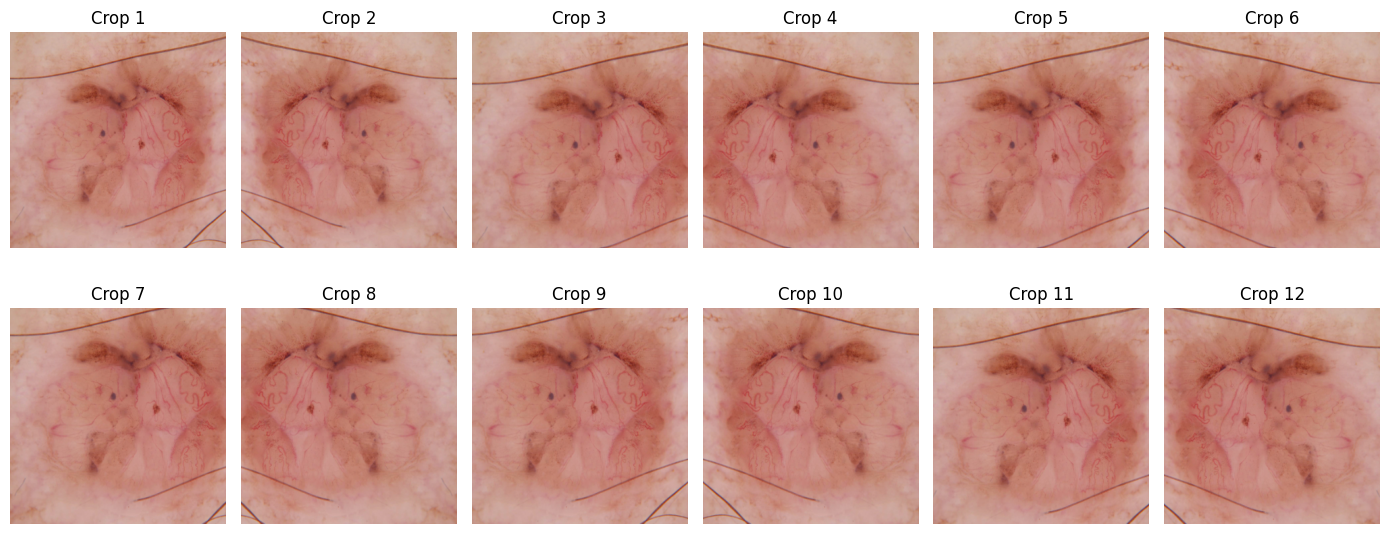

In [9]:
sample_row = test_df.sample(1, random_state=SEED).iloc[0]

base_img = preprocess_base_image(sample_row["image_path"], sample_row["mask_path"])

windows = generate_multicrop_images_from_base(
    base_img,
    target_size=IMG_SIZE_A,
    local_crop_ratio=LOCAL_CROP_RATIO,
    include_full=INCLUDE_FULL_IMAGE,
    use_horizontal_flip=USE_HORIZONTAL_FLIP,
    use_vertical_flip=USE_VERTICAL_FLIP,
    use_hv_flip=USE_HV_FLIP
)

print("Quantidade de imagens geradas:", len(windows))
print("Shape:", windows.shape)

n_show = min(len(windows), 12)

plt.figure(figsize=(14, 6))

for i in range(n_show):
    plt.subplot(2, 6, i + 1)
    plt.imshow(np.clip(windows[i], 0, 255).astype("uint8"))
    plt.title(f"Crop {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("exemplo_multicrop_tta.png", dpi=300, bbox_inches="tight")
plt.show()

## 10. Carregar modelos

In [10]:
feature_extractor_a = keras.models.load_model(FEATURE_EXTRACTOR_A_PATH)
classifier_a = keras.models.load_model(CLASSIFIER_A_PATH)

feature_extractor_b = keras.models.load_model(FEATURE_EXTRACTOR_B_PATH)
classifier_b = keras.models.load_model(CLASSIFIER_B_PATH)

feature_extractor_c = keras.models.load_model(FEATURE_EXTRACTOR_C_PATH)
classifier_c = keras.models.load_model(CLASSIFIER_C_PATH)

print("Modelo A input:", feature_extractor_a.input_shape)
print("Modelo B input:", feature_extractor_b.input_shape)
print("Modelo C input:", feature_extractor_c.input_shape)

Modelo A input: (None, 320, 320, 3)
Modelo B input: (None, 256, 256, 3)
Modelo C input: (None, 380, 380, 3)


## 11. Predição com multi-crop TTA

In [11]:
def predict_model_with_multicrop_tta(
    image_path,
    mask_path,
    img_size,
    feature_extractor,
    classifier
):
    base_img = preprocess_base_image(image_path, mask_path)

    tta_images = generate_multicrop_images_from_base(
        base_img,
        target_size=img_size,
        local_crop_ratio=LOCAL_CROP_RATIO,
        include_full=INCLUDE_FULL_IMAGE,
        use_horizontal_flip=USE_HORIZONTAL_FLIP,
        use_vertical_flip=USE_VERTICAL_FLIP,
        use_hv_flip=USE_HV_FLIP
    )

    features = feature_extractor.predict(tta_images, verbose=0)
    preds = classifier.predict(features, verbose=0)

    return np.mean(preds, axis=0)


def predict_ensemble_multicrop_tta(image_path, mask_path):
    pred_a = predict_model_with_multicrop_tta(
        image_path=image_path,
        mask_path=mask_path,
        img_size=IMG_SIZE_A,
        feature_extractor=feature_extractor_a,
        classifier=classifier_a
    )

    pred_b = predict_model_with_multicrop_tta(
        image_path=image_path,
        mask_path=mask_path,
        img_size=IMG_SIZE_B,
        feature_extractor=feature_extractor_b,
        classifier=classifier_b
    )

    pred_c = predict_model_with_multicrop_tta(
        image_path=image_path,
        mask_path=mask_path,
        img_size=IMG_SIZE_C,
        feature_extractor=feature_extractor_c,
        classifier=classifier_c
    )

    final_pred = (
        (WEIGHT_MODEL_A * pred_a) +
        (WEIGHT_MODEL_B * pred_b) +
        (WEIGHT_MODEL_C * pred_c)
    )

    return final_pred

## 12. Teste rápido em uma imagem

In [12]:
sample_row = test_df.iloc[0]

sample_pred = predict_ensemble_multicrop_tta(
    sample_row["image_path"],
    sample_row["mask_path"]
)

print("Shape da predição:", sample_pred.shape)
print("Soma:", sample_pred.sum())
print("Classe real:", sample_row["class_name"])
print("Classe predita:", class_name[int(np.argmax(sample_pred))])

Shape da predição: (7,)
Soma: 0.99999994
Classe real: NV
Classe predita: NV


## 13. Avaliação no conjunto de teste

In [13]:
y_true_multicrop = []
y_pred_multicrop = []

for _, row in test_df.reset_index(drop=True).iterrows():
    pred = predict_ensemble_multicrop_tta(row["image_path"], row["mask_path"])
    pred_class = np.argmax(pred)

    y_true_multicrop.append(int(row["label"]))
    y_pred_multicrop.append(pred_class)

y_true_multicrop = np.array(y_true_multicrop)
y_pred_multicrop = np.array(y_pred_multicrop)

print("Avaliação com multi-crop TTA concluída.")

Avaliação com multi-crop TTA concluída.


## 14. Relatório de classificação

In [14]:
print("Relatório de Classificação do Ensemble com Multi-Crop TTA:")
print(classification_report(
    y_true_multicrop,
    y_pred_multicrop,
    target_names=classes,
    digits=4,
    zero_division=0
))

acc_multicrop = accuracy_score(y_true_multicrop, y_pred_multicrop)

macro_precision_multicrop = precision_score(y_true_multicrop, y_pred_multicrop, average="macro", zero_division=0)
macro_recall_multicrop = recall_score(y_true_multicrop, y_pred_multicrop, average="macro", zero_division=0)
macro_f1_multicrop = f1_score(y_true_multicrop, y_pred_multicrop, average="macro", zero_division=0)

weighted_precision_multicrop = precision_score(y_true_multicrop, y_pred_multicrop, average="weighted", zero_division=0)
weighted_recall_multicrop = recall_score(y_true_multicrop, y_pred_multicrop, average="weighted", zero_division=0)
weighted_f1_multicrop = f1_score(y_true_multicrop, y_pred_multicrop, average="weighted", zero_division=0)

print("\nMÉTRICAS GERAIS DO ENSEMBLE COM MULTI-CROP TTA")
print(f"Accuracy: {acc_multicrop:.4f}")

print("\nMacro Average:")
print(f"  Precision: {macro_precision_multicrop:.4f}")
print(f"  Recall: {macro_recall_multicrop:.4f}")
print(f"  F1-Score: {macro_f1_multicrop:.4f}")

print("\nWeighted Average:")
print(f"  Precision: {weighted_precision_multicrop:.4f}")
print(f"  Recall: {weighted_recall_multicrop:.4f}")
print(f"  F1-Score: {weighted_f1_multicrop:.4f}")

Relatório de Classificação do Ensemble com Multi-Crop TTA:
              precision    recall  f1-score   support

         MEL     0.8065    0.6726    0.7335       223
          NV     0.9259    0.9694    0.9472      1341
         BCC     0.7949    0.9029    0.8455       103
       AKIEC     0.6818    0.6923    0.6870        65
         BKL     0.8033    0.6682    0.7295       220
          DF     0.9474    0.7826    0.8571        23
        VASC     0.9286    0.9286    0.9286        28

    accuracy                         0.8882      2003
   macro avg     0.8412    0.8024    0.8183      2003
weighted avg     0.8848    0.8882    0.8845      2003


MÉTRICAS GERAIS DO ENSEMBLE COM MULTI-CROP TTA
Accuracy: 0.8882

Macro Average:
  Precision: 0.8412
  Recall: 0.8024
  F1-Score: 0.8183

Weighted Average:
  Precision: 0.8848
  Recall: 0.8882
  F1-Score: 0.8845


## 15. Matriz de confusão em porcentagem

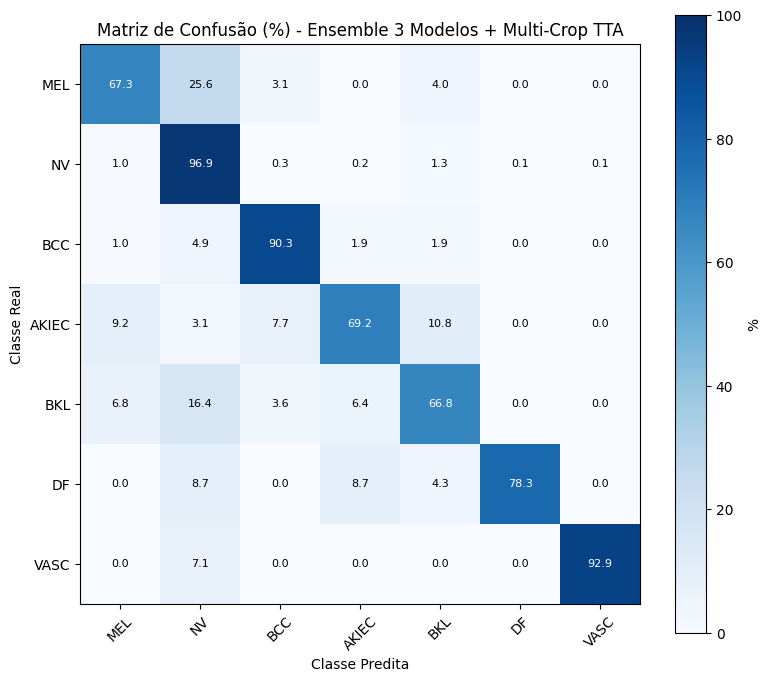

In [15]:
cm_multicrop = confusion_matrix(y_true_multicrop, y_pred_multicrop, labels=list(range(len(classes))))
cm_percent_multicrop = cm_multicrop.astype("float") / cm_multicrop.sum(axis=1, keepdims=True) * 100
cm_percent_multicrop = np.nan_to_num(cm_percent_multicrop)

plt.figure(figsize=(8, 7))
im = plt.imshow(cm_percent_multicrop, interpolation="nearest", cmap="Blues", vmin=0, vmax=100)

plt.title("Matriz de Confusão (%) - Ensemble 3 Modelos + Multi-Crop TTA")
plt.colorbar(im, label="%")

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

for i in range(cm_percent_multicrop.shape[0]):
    for j in range(cm_percent_multicrop.shape[1]):
        color = "white" if cm_percent_multicrop[i, j] > 50 else "black"
        plt.text(j, i, f"{cm_percent_multicrop[i, j]:.1f}", ha="center", va="center", color=color, fontsize=8)

plt.ylabel("Classe Real")
plt.xlabel("Classe Predita")
plt.tight_layout()
plt.savefig("matriz_confusao_percent_ensemble_3_modelos_multicrop_tta.png", dpi=300, bbox_inches="tight")
plt.show()

## 16. Comparação com o melhor ensemble anterior

In [16]:
print("Melhor ensemble anterior com TTA tradicional:")
print("DenseNet201/DenseNet169/EfficientNetB4 + TTA")
print("Pesos: 0.60 / 0.30 / 0.10")
print("Accuracy: 0.8832")
print("F1 macro: 0.8217")
print("F1 ponderado: 0.8800")

print("\nResultado com Multi-Crop TTA:")
print(f"Accuracy: {acc_multicrop:.4f}")
print(f"F1 macro: {macro_f1_multicrop:.4f}")
print(f"F1 ponderado: {weighted_f1_multicrop:.4f}")

print("\nConfiguração:")
print("LOCAL_CROP_RATIO:", LOCAL_CROP_RATIO)
print("INCLUDE_FULL_IMAGE:", INCLUDE_FULL_IMAGE)
print("USE_HORIZONTAL_FLIP:", USE_HORIZONTAL_FLIP)
print("USE_VERTICAL_FLIP:", USE_VERTICAL_FLIP)
print("USE_HV_FLIP:", USE_HV_FLIP)
print("Pesos:", WEIGHT_MODEL_A, WEIGHT_MODEL_B, WEIGHT_MODEL_C)

Melhor ensemble anterior com TTA tradicional:
DenseNet201/DenseNet169/EfficientNetB4 + TTA
Pesos: 0.60 / 0.30 / 0.10
Accuracy: 0.8832
F1 macro: 0.8217
F1 ponderado: 0.8800

Resultado com Multi-Crop TTA:
Accuracy: 0.8882
F1 macro: 0.8183
F1 ponderado: 0.8845

Configuração:
LOCAL_CROP_RATIO: 0.9
INCLUDE_FULL_IMAGE: True
USE_HORIZONTAL_FLIP: True
USE_VERTICAL_FLIP: False
USE_HV_FLIP: False
Pesos: 0.7 0.2 0.1


## 17. Salvar resultados

In [17]:
EXPERIMENT_NAME = (
    f"ensemble_3_modelos_multicrop_ratio{LOCAL_CROP_RATIO}_"
    f"A{WEIGHT_MODEL_A}_B{WEIGHT_MODEL_B}_C{WEIGHT_MODEL_C}"
).replace(".", "p")

RESULTS_DIR = Path("resultados_multicrop_tta")
RESULTS_DIR.mkdir(exist_ok=True)

predictions_df = test_df.reset_index(drop=True).copy()
predictions_df["y_true"] = y_true_multicrop
predictions_df["y_pred"] = y_pred_multicrop
predictions_df["class_true"] = [class_name[int(label)] for label in y_true_multicrop]
predictions_df["class_pred"] = [class_name[int(label)] for label in y_pred_multicrop]
predictions_df["correct"] = predictions_df["y_true"] == predictions_df["y_pred"]

predictions_path = RESULTS_DIR / f"{EXPERIMENT_NAME}_predictions.csv"
predictions_df.to_csv(predictions_path, index=False)

metrics = {
    "experiment_name": EXPERIMENT_NAME,
    "date": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "configuration": {
        "model_a": {
            "name": "DenseNet201 + Crop + SMOTE",
            "img_size": IMG_SIZE_A,
            "feature_extractor": FEATURE_EXTRACTOR_A_PATH,
            "classifier": CLASSIFIER_A_PATH,
            "weight": WEIGHT_MODEL_A
        },
        "model_b": {
            "name": "DenseNet169 + Crop + SMOTE",
            "img_size": IMG_SIZE_B,
            "feature_extractor": FEATURE_EXTRACTOR_B_PATH,
            "classifier": CLASSIFIER_B_PATH,
            "weight": WEIGHT_MODEL_B
        },
        "model_c": {
            "name": "EfficientNetB4 + Crop + SMOTE",
            "img_size": IMG_SIZE_C,
            "feature_extractor": FEATURE_EXTRACTOR_C_PATH,
            "classifier": CLASSIFIER_C_PATH,
            "weight": WEIGHT_MODEL_C
        },
        "use_dull_razor": USE_DULL_RAZOR,
        "use_mask_segmentation": USE_MASK_SEGMENTATION,
        "use_mask_crop": USE_MASK_CROP,
        "crop_margin": CROP_MARGIN,
        "multicrop_tta": True,
        "local_crop_ratio": LOCAL_CROP_RATIO,
        "include_full_image": INCLUDE_FULL_IMAGE,
        "use_horizontal_flip": USE_HORIZONTAL_FLIP,
        "use_vertical_flip": USE_VERTICAL_FLIP,
        "use_hv_flip": USE_HV_FLIP
    },
    "metrics": {
        "accuracy": float(acc_multicrop),
        "macro_precision": float(macro_precision_multicrop),
        "macro_recall": float(macro_recall_multicrop),
        "macro_f1": float(macro_f1_multicrop),
        "weighted_precision": float(weighted_precision_multicrop),
        "weighted_recall": float(weighted_recall_multicrop),
        "weighted_f1": float(weighted_f1_multicrop)
    }
}

metrics_path = RESULTS_DIR / f"{EXPERIMENT_NAME}_metrics.json"

with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=4, ensure_ascii=False)

cm_path = RESULTS_DIR / f"{EXPERIMENT_NAME}_confusion_matrix_percent.csv"
pd.DataFrame(cm_percent_multicrop, index=classes, columns=classes).to_csv(cm_path)

print("Resultados salvos com sucesso:")
print("Predições:", predictions_path)
print("Métricas:", metrics_path)
print("Matriz de confusão:", cm_path)

Resultados salvos com sucesso:
Predições: resultados_multicrop_tta/ensemble_3_modelos_multicrop_ratio0p9_A0p7_B0p2_C0p1_predictions.csv
Métricas: resultados_multicrop_tta/ensemble_3_modelos_multicrop_ratio0p9_A0p7_B0p2_C0p1_metrics.json
Matriz de confusão: resultados_multicrop_tta/ensemble_3_modelos_multicrop_ratio0p9_A0p7_B0p2_C0p1_confusion_matrix_percent.csv


## 18. Próximos testes sugeridos

Se o resultado melhorar, mantenha a configuração.

Se piorar, teste variações leves:

```python
LOCAL_CROP_RATIO = 0.85
USE_HORIZONTAL_FLIP = True
USE_VERTICAL_FLIP = False
USE_HV_FLIP = False
```

Depois:

```python
LOCAL_CROP_RATIO = 0.90
```

Se o desempenho cair muito, significa que o modelo depende mais da lesão inteira do que de regiões locais. Nesse caso, mantenha o TTA tradicional.